## Kleiber’s Law (Metabolic Rate vs Body Mass)

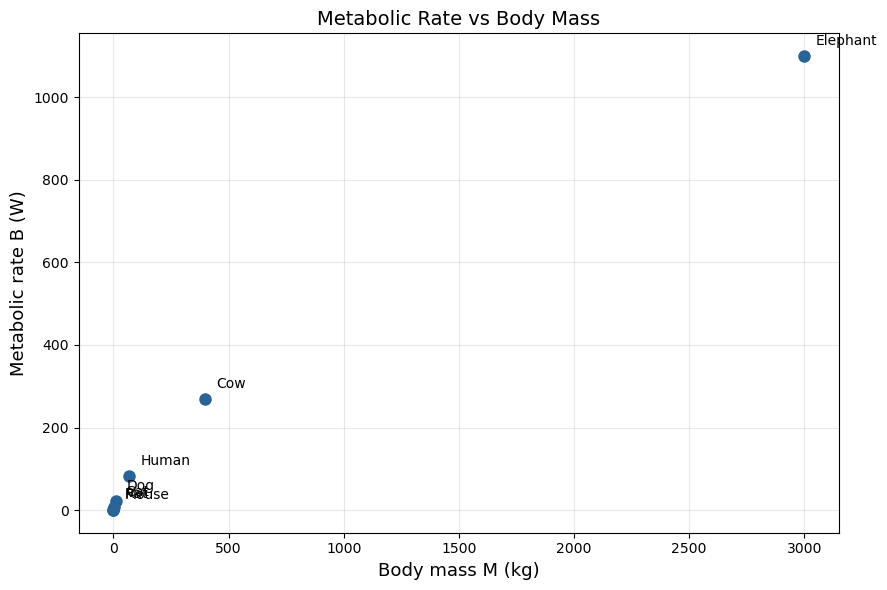

In [1]:
import matplotlib.pyplot as plt

# Data: Kleiber's metabolic scaling
animals = ["Mouse", "Rat", "Cat", "Dog", "Human", "Cow", "Elephant"]
M = [0.025, 0.3, 3, 11, 70, 400, 3000]       # body mass (kg)
B = [0.24, 1.45, 8.0, 22.7, 82, 270, 1100]    # metabolic rate (W)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(M, B, 'o', markersize=8, color='#2a6496')

for name, m, b in zip(animals, M, B):
    ax.annotate(name, (m, b), textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_xlabel("Body mass M (kg)", fontsize=13)
ax.set_ylabel("Metabolic rate B (W)", fontsize=13)
ax.set_title("Metabolic Rate vs Body Mass", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Mouse, Rat, Cat, and Dog are all crushed into the bottom-left corner while Elephant dominates.

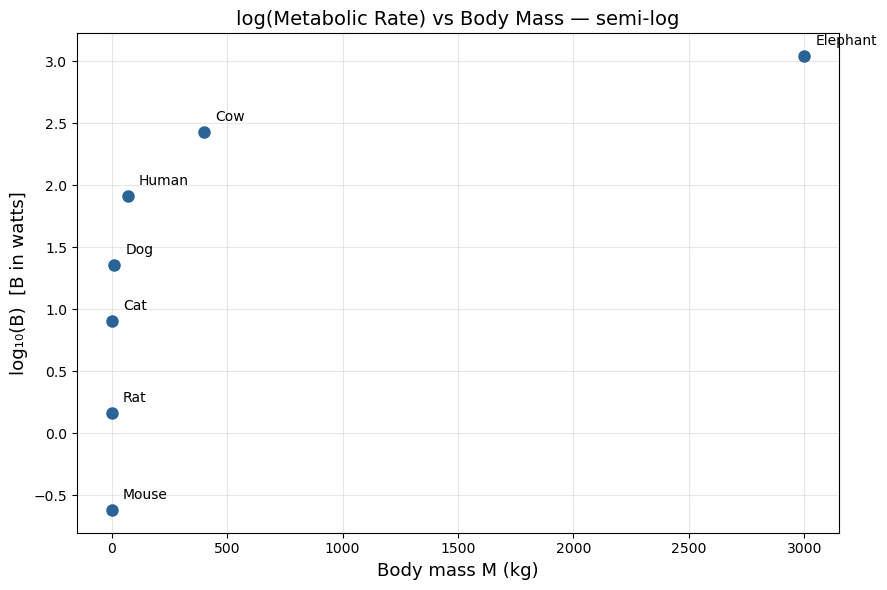

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data: Kleiber's metabolic scaling
animals = ["Mouse", "Rat", "Cat", "Dog", "Human", "Cow", "Elephant"]
M = np.array([0.025, 0.3, 3, 11, 70, 400, 3000])       # body mass (kg)
B = np.array([0.24, 1.45, 8.0, 22.7, 82, 270, 1100])    # metabolic rate (W)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(M, np.log10(B), 'o', markersize=8, color='#2a6496')

for name, m, b in zip(animals, M, B):
    ax.annotate(name, (m, np.log10(b)), textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_xlabel("Body mass M (kg)", fontsize=13)
ax.set_ylabel("log₁₀(B)  [B in watts]", fontsize=13)
ax.set_title("log(Metabolic Rate) vs Body Mass — semi-log", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

The small animals are a bit more visible now, but the points still curve. This confirms this isn't an exponential relationship (which would appear as a straight line here).

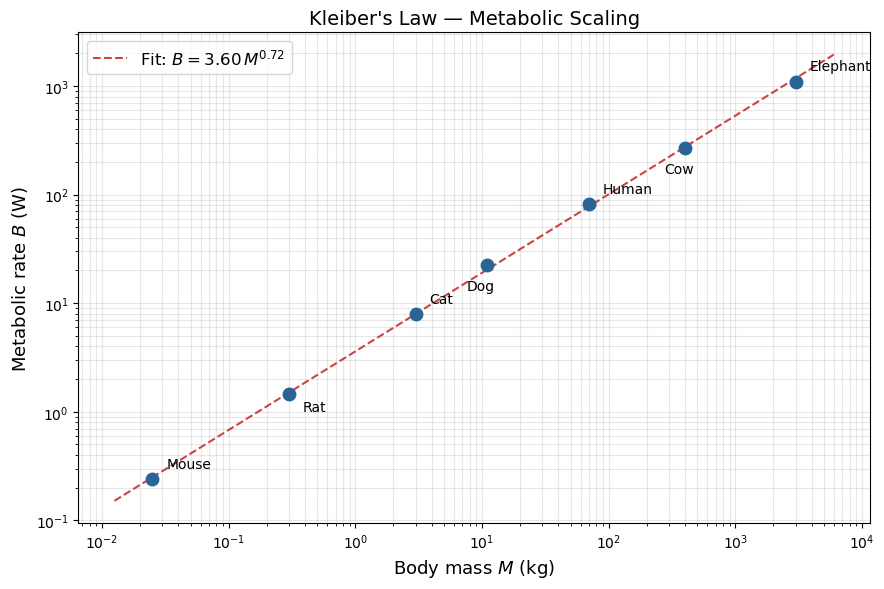

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data: Kleiber's metabolic scaling
animals = ["Mouse", "Rat", "Cat", "Dog", "Human", "Cow", "Elephant"]
M = np.array([0.025, 0.3, 3, 11, 70, 400, 3000])       # body mass (kg)
B = np.array([0.24, 1.45, 8.0, 22.7, 82, 270, 1100])    # metabolic rate (W)

# Log-log linear fit: log(B) = a * log(M) + b
coeffs = np.polyfit(np.log10(M), np.log10(B), 1)
exponent, log_prefactor = coeffs
prefactor = 10 ** log_prefactor

# Fit line over a smooth range
M_fit = np.logspace(np.log10(M.min()) - 0.3, np.log10(M.max()) + 0.3, 200)
B_fit = prefactor * M_fit ** exponent

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(M, B, 'o', markersize=9, color='#2a6496', zorder=5)
ax.loglog(M_fit, B_fit, '--', color='#cc4444', linewidth=1.5,
          # label=f"Fit: $B = {prefactor:.2f} \\, M^{{{exponent:.2f}}}$")
          label = "Fit: $B = %.2f \\, M^{%.2f}$" % (prefactor, exponent))

# Annotate each animal
offsets = {
    "Mouse": (10, 8), "Rat": (10, -12), "Cat": (10, 8),
    "Dog": (-15, -18), "Human": (10, 8), "Cow": (-15, -18), "Elephant": (10, 8),
}
for name, m, b in zip(animals, M, B):
    dx, dy = offsets[name]
    ax.annotate(name, (m, b), textcoords="offset points", xytext=(dx, dy), fontsize=10)

ax.set_xlabel("Body mass $M$ (kg)", fontsize=13)
ax.set_ylabel("Metabolic rate $B$ (W)", fontsize=13)
ax.set_title("Kleiber's Law — Metabolic Scaling", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Gutenberg-Richter Law (Earthquake Magnitudes)

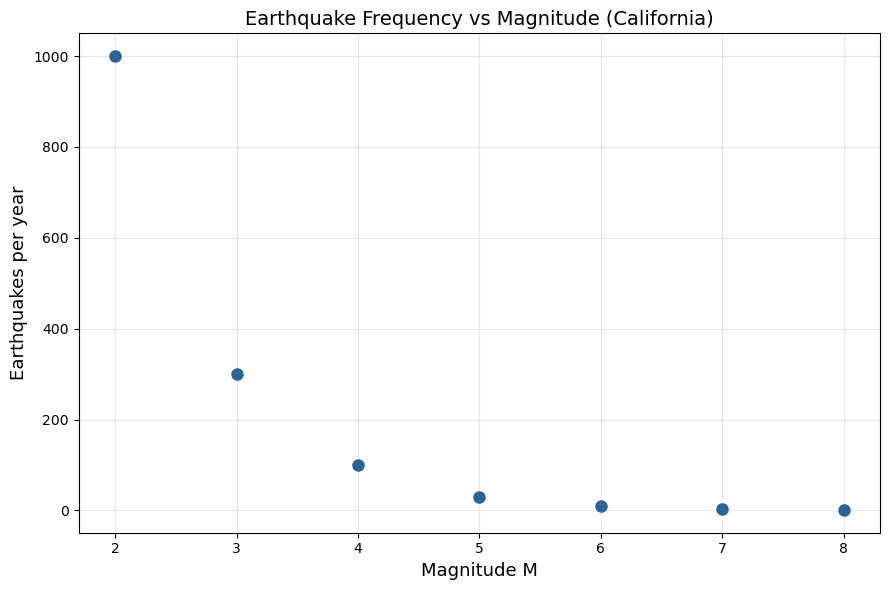

In [4]:
import matplotlib.pyplot as plt

# Gutenberg-Richter: earthquake frequency in California
magnitude = [2, 3, 4, 5, 6, 7, 8]
quakes_per_year = [1000, 300, 100, 30, 10, 3, 1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(magnitude, quakes_per_year, 'o', markersize=8, color='#2a6496')

ax.set_xlabel("Magnitude M", fontsize=13)
ax.set_ylabel("Earthquakes per year", fontsize=13)
ax.set_title("Earthquake Frequency vs Magnitude (California)", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

Same story as the metabolic data in linear scale: the small magnitudes crush everything else. 

This sets up nicely a switch to log scale on the y-axis next, where the Gutenberg-Richter law will show up as a clean straight line.

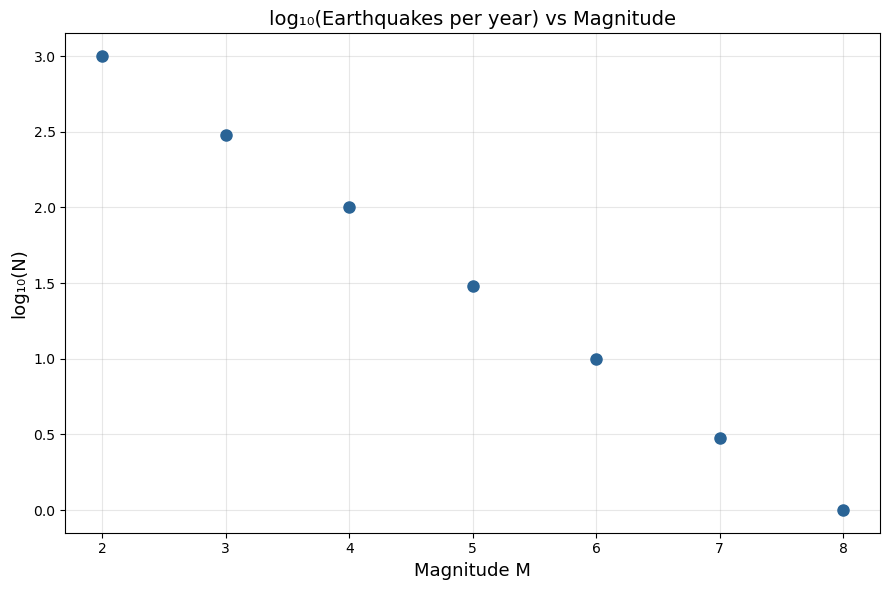

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Gutenberg-Richter: earthquake frequency in California
magnitude = np.array([2, 3, 4, 5, 6, 7, 8])
quakes_per_year = np.array([1000, 300, 100, 30, 10, 3, 1])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(magnitude, np.log10(quakes_per_year), 'o', markersize=8, color='#2a6496')

ax.set_xlabel("Magnitude M", fontsize=13)
ax.set_ylabel("log₁₀(N)", fontsize=13)
ax.set_title("log₁₀(Earthquakes per year) vs Magnitude", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Heavy Tail

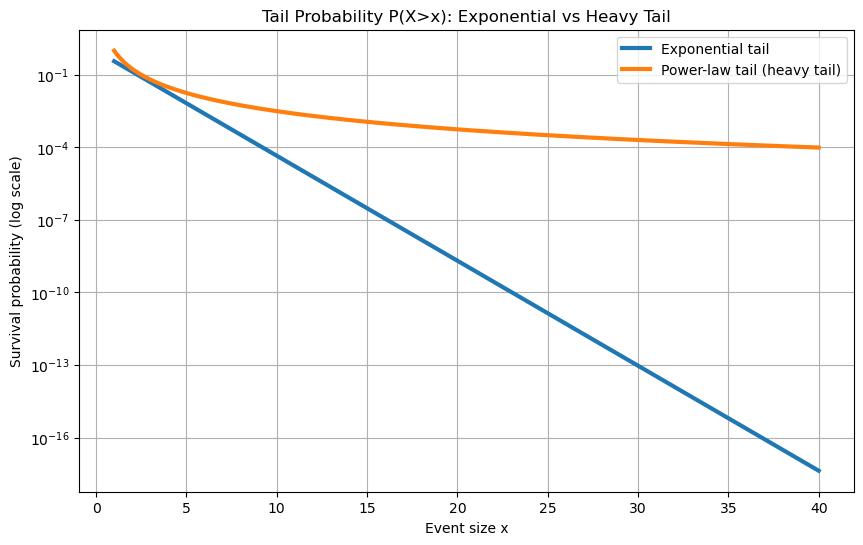

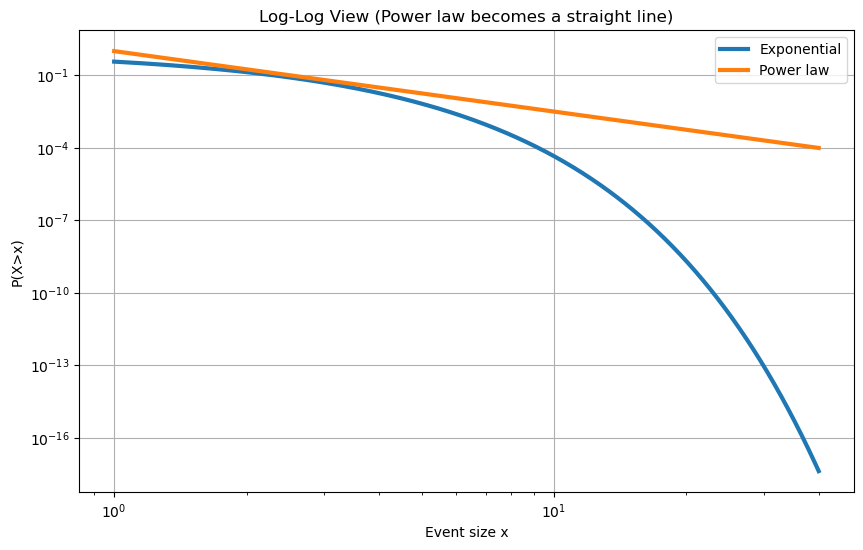

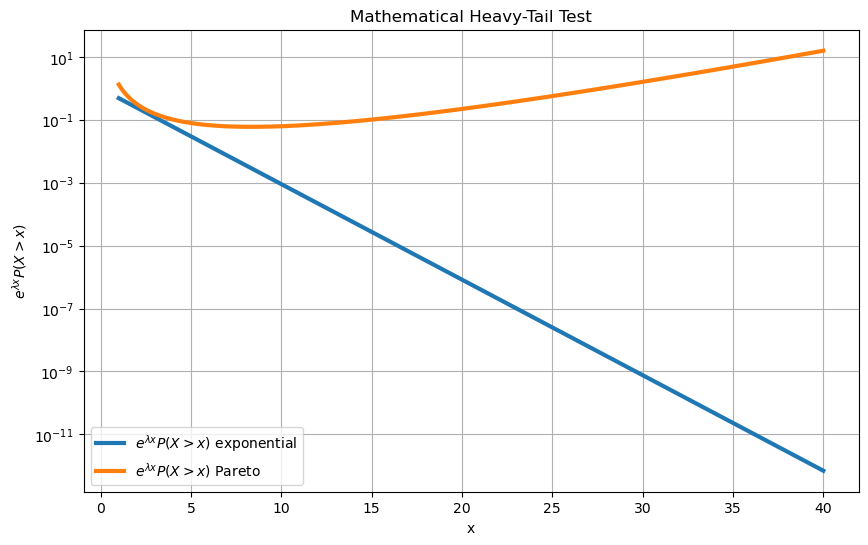


Probability of very large events:

Threshold x > 5
Exponential : 6.738e-03
Power law   : 1.789e-02
Power-law is 2.7 times larger

Threshold x > 10
Exponential : 4.540e-05
Power law   : 3.162e-03
Power-law is 69.7 times larger

Threshold x > 20
Exponential : 2.061e-09
Power law   : 5.590e-04
Power-law is 271215.6 times larger

Interpretation:
In a heavy-tailed model, catastrophic earthquakes remain much
more probable than an exponential model would suggest.
That is the sense in which the tail is 'heavy'.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
alpha = 2.5          # Pareto tail exponent
lam_exp = 1.0        # Exponential decay rate
lam_test = 0.3       # Lambda used in the heavy-tail definition

x = np.linspace(1, 40, 1000)

# -----------------------------
# Survival functions P(X>x)
# -----------------------------
# Exponential tail
S_exp = np.exp(-lam_exp * x)

# Pareto tail (power law)
S_par = x**(-alpha)

# -----------------------------
# Plot 1: Tail probabilities
# -----------------------------
plt.figure(figsize=(10,6))
plt.semilogy(x, S_exp, label='Exponential tail', linewidth=3)
plt.semilogy(x, S_par, label='Power-law tail (heavy tail)', linewidth=3)

plt.title("Tail Probability P(X>x): Exponential vs Heavy Tail")
plt.xlabel("Event size x")
plt.ylabel("Survival probability (log scale)")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Plot 2: Log-log reveals power law
# -----------------------------
plt.figure(figsize=(10,6))
plt.loglog(x, S_exp, label='Exponential', linewidth=3)
plt.loglog(x, S_par, label='Power law', linewidth=3)

plt.title("Log-Log View (Power law becomes a straight line)")
plt.xlabel("Event size x")
plt.ylabel("P(X>x)")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Illustration of heavy-tail definition:
# exp(lambda x) * P(X>x)
# -----------------------------
test_exp = np.exp(lam_test*x) * S_exp
test_par = np.exp(lam_test*x) * S_par

plt.figure(figsize=(10,6))
plt.yscale('log')
plt.plot(x, test_exp, label=r'$e^{\lambda x} P(X>x)$ exponential', linewidth=3)
plt.plot(x, test_par, label=r'$e^{\lambda x} P(X>x)$ Pareto', linewidth=3)

plt.title("Mathematical Heavy-Tail Test")
plt.xlabel("x")
plt.ylabel(r'$e^{\lambda x} P(X>x)$')
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# Extreme-event comparison
# -----------------------------
thresholds = [5, 10, 20]

print("\nProbability of very large events:")
for t in thresholds:
    p_exp = np.exp(-lam_exp*t)
    p_par = t**(-alpha)

    print(f"\nThreshold x > {t}")
    print(f"Exponential : {p_exp:.3e}")
    print(f"Power law   : {p_par:.3e}")
    print(f"Power-law is {p_par/p_exp:.1f} times larger")


# -----------------------------
# Optional: earthquake interpretation
# -----------------------------
print("\nInterpretation:")
print("In a heavy-tailed model, catastrophic earthquakes remain much")
print("more probable than an exponential model would suggest.")
print("That is the sense in which the tail is 'heavy'.")

## Power Law vs Exponential

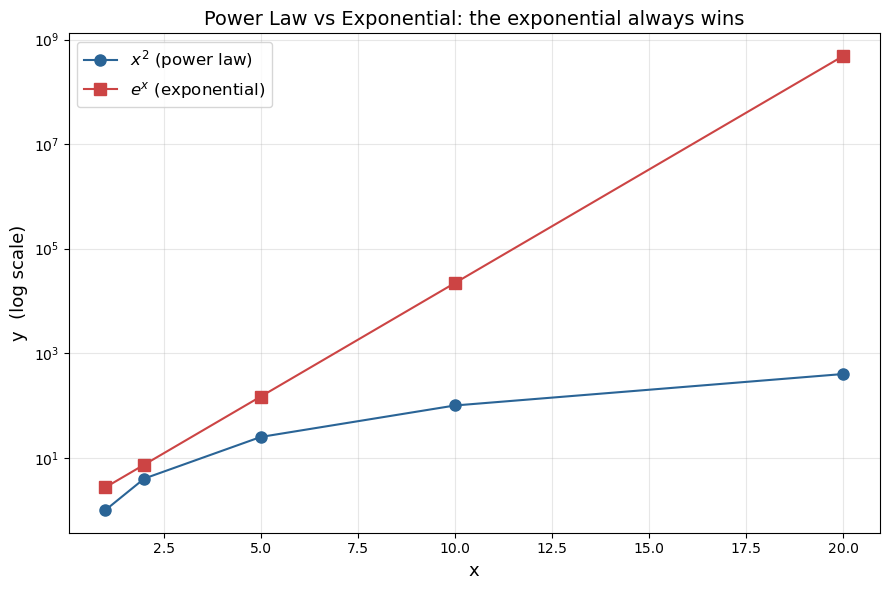

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Comparison: power law vs exponential
x = np.array([1, 2, 5, 10, 20])
power = x ** 2
expo = np.exp(x)

fig, ax = plt.subplots(figsize=(9, 6))
ax.semilogy(x, power, 'o-', markersize=8, color='#2a6496', label='$x^2$ (power law)')
ax.semilogy(x, expo, 's-', markersize=8, color='#cc4444', label='$e^x$ (exponential)')

ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y  (log scale)", fontsize=13)
ax.set_title("Power Law vs Exponential: the exponential always wins", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## Scale Invariance

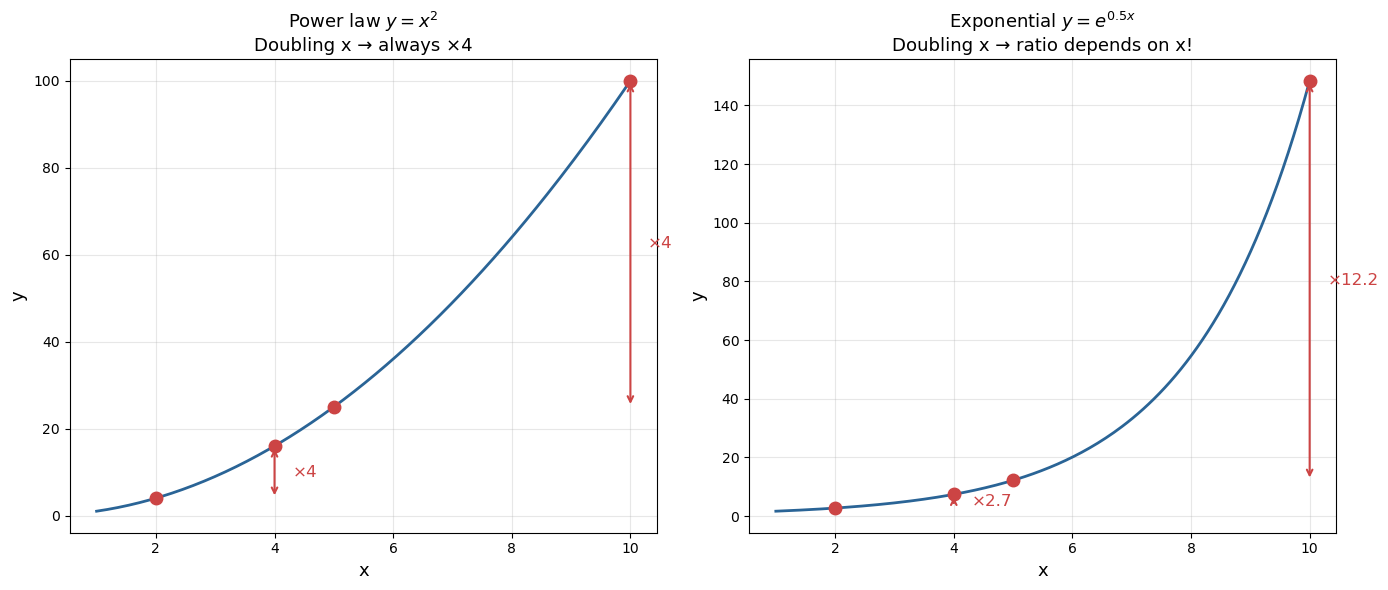

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Scale invariance: power law vs exponential
x = np.linspace(1, 10, 200)
alpha = 2
lam = 0.5

y_power = x ** alpha
y_expo = np.exp(lam * x)

# Pick two starting points, double each
x1, x2 = 2, 5
k = 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: Power law ---
ax = axes[0]
ax.plot(x, y_power, '-', color='#2a6496', linewidth=2)
for xi in [x1, x2]:
    y_lo = xi ** alpha
    y_hi = (k * xi) ** alpha
    ratio = y_hi / y_lo
    ax.plot([xi, k * xi], [y_lo, y_hi], 'o', markersize=9, color='#cc4444')
    ax.annotate('', xy=(k * xi, y_hi), xytext=(k * xi, y_lo),
                arrowprops=dict(arrowstyle='<->', color='#cc4444', lw=1.5))
    ax.text(k * xi + 0.3, (y_lo + y_hi) / 2, f'×{ratio:.0f}',
            color='#cc4444', fontsize=12, va='center')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title(f'Power law $y = x^{{{alpha}}}$\nDoubling x → always ×{k**alpha}', fontsize=13)
ax.grid(True, alpha=0.3)

# --- Right panel: Exponential ---
ax = axes[1]
ax.plot(x, y_expo, '-', color='#2a6496', linewidth=2)
for xi in [x1, x2]:
    y_lo = np.exp(lam * xi)
    y_hi = np.exp(lam * k * xi)
    ratio = y_hi / y_lo
    ax.plot([xi, k * xi], [y_lo, y_hi], 'o', markersize=9, color='#cc4444')
    ax.annotate('', xy=(k * xi, y_hi), xytext=(k * xi, y_lo),
                arrowprops=dict(arrowstyle='<->', color='#cc4444', lw=1.5))
    ax.text(k * xi + 0.3, (y_lo + y_hi) / 2, f'×{ratio:.1f}',
            color='#cc4444', fontsize=12, va='center')

ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title(f'Exponential $y = e^{{{lam}x}}$\nDoubling x → ratio depends on x!', fontsize=13)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

On the left, both red arrows show the same ×4 ratio (since $2^2 = 4$) whether you start at $x=2$ or $x=5$ — that's scale invariance. On the right, the same doubling produces very different ratios depending on where you start — the exponential breaks scale invariance.

## How to Distinguish a Power Law from an Exponential?

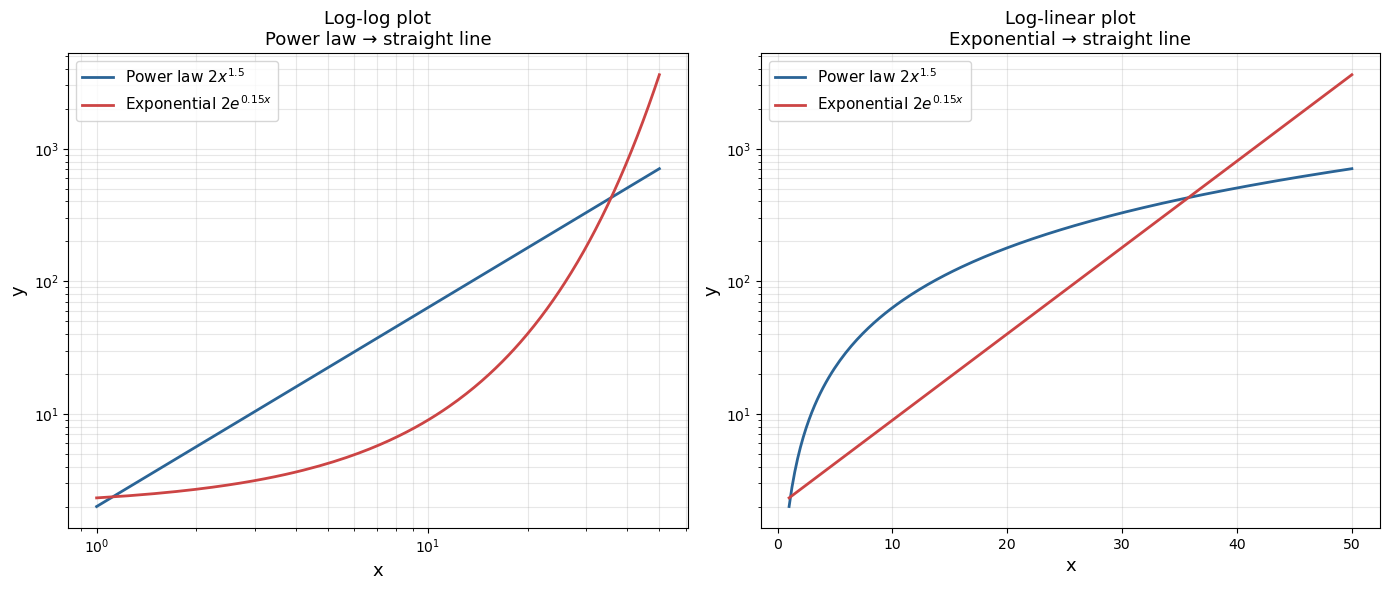

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 50, 200)
y_power = 2 * x ** 1.5          # power law: C=2, alpha=1.5
y_expo = 2 * np.exp(0.15 * x)   # exponential: C=2, lambda=0.15

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: log-log plot ---
ax = axes[0]
ax.loglog(x, y_power, '-', color='#2a6496', linewidth=2, label='Power law $2x^{1.5}$')
ax.loglog(x, y_expo, '-', color='#cc4444', linewidth=2, label='Exponential $2e^{0.15x}$')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Log-log plot\nPower law → straight line', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

# --- Right: log-linear plot ---
ax = axes[1]
ax.semilogy(x, y_power, '-', color='#2a6496', linewidth=2, label='Power law $2x^{1.5}$')
ax.semilogy(x, y_expo, '-', color='#cc4444', linewidth=2, label='Exponential $2e^{0.15x}$')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title('Log-linear plot\nExponential → straight line', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.show()

## Worked example

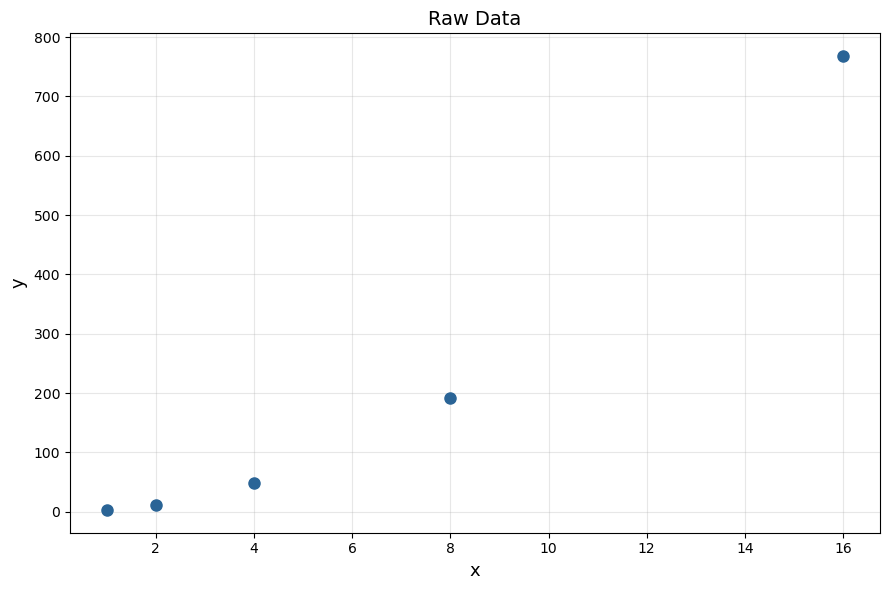

In [10]:
import matplotlib.pyplot as plt

x = [1, 2, 4, 8, 16]
y = [3, 12, 48, 192, 768]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(x, y, 'o', markersize=8, color='#2a6496')

ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y", fontsize=13)
ax.set_title("Raw Data", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

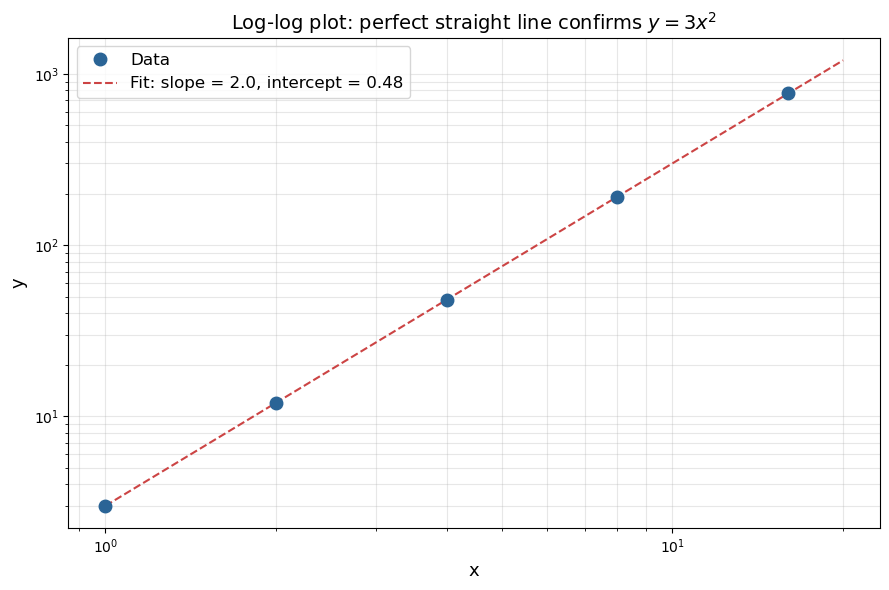

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 4, 8, 16])
y = np.array([3, 12, 48, 192, 768])

# Linear fit in log-log space
coeffs = np.polyfit(np.log10(x), np.log10(y), 1)
slope, intercept = coeffs

# Fit line
x_fit = np.logspace(0, np.log10(20), 100)
y_fit = 10 ** (slope * np.log10(x_fit) + intercept)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(x, y, 'o', markersize=9, color='#2a6496', zorder=5, label='Data')
ax.loglog(x_fit, y_fit, '--', color='#cc4444', linewidth=1.5,
          label=f'Fit: slope = {slope:.1f}, intercept = {intercept:.2f}')

ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y", fontsize=13)
ax.set_title("Log-log plot: perfect straight line confirms $y = 3x^2$", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()

## Fitting: How to Determine That a Phenomenon Follows a Power Law

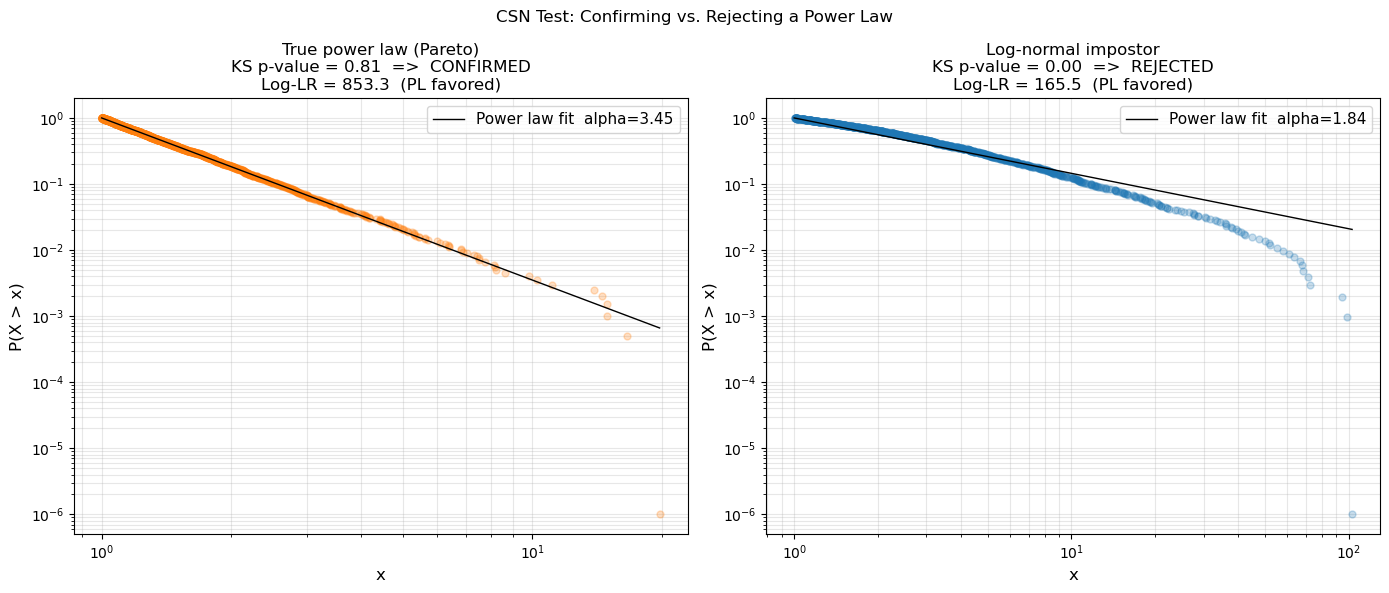

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)
xmin = 1.0
n = 2000

# --- Case 1: true power law (Pareto, alpha=2.5) ---
alpha_true = 2.5
u = rng.uniform(0, 1, n)
data_pl = xmin * (1 - u) ** (-1 / alpha_true)

# --- Case 2: log-normal impostor ---
data_ln = rng.lognormal(mean=0.0, sigma=1.5, size=n)
data_ln = data_ln[data_ln >= xmin]


def mle_alpha(data, xmin):
    """Clauset-Shalizi-Newman MLE for power-law exponent."""
    x = data[data >= xmin]
    return 1 + len(x) / np.sum(np.log(x / xmin))


def ks_pvalue(data, xmin, alpha_hat, n_boot=400):
    """Bootstrap p-value for KS goodness-of-fit."""
    x = np.sort(data[data >= xmin])
    n = len(x)
    ecdf = np.arange(1, n + 1) / n
    tcdf = 1 - (xmin / x) ** (alpha_hat - 1)
    ks_obs = np.max(np.abs(ecdf - tcdf))
    count = 0
    for _ in range(n_boot):
        boot = xmin * rng.uniform(0, 1, n) ** (-1 / alpha_hat)
        a_b = mle_alpha(boot, xmin)
        xb = np.sort(boot)
        ecdf_b = np.arange(1, n + 1) / n
        tcdf_b = 1 - (xmin / xb) ** (a_b - 1)
        if np.max(np.abs(ecdf_b - tcdf_b)) >= ks_obs:
            count += 1
    return ks_obs, count / n_boot


def loglik_pl(data, xmin, alpha):
    x = data[data >= xmin]
    n = len(x)
    return n * np.log(alpha - 1) - n * np.log(xmin) - alpha * np.sum(np.log(x / xmin))


def loglik_ln(data, xmin):
    x = data[data >= xmin]
    mu = np.mean(np.log(x))
    sigma = np.std(np.log(x), ddof=1)
    return np.sum(stats.lognorm.logpdf(x, s=sigma, scale=np.exp(mu)))


results = []
for data, label, color in [
    (data_pl, "True power law (Pareto)", "#FF7F0E"),
    (data_ln, "Log-normal impostor",     "#1F77B4"),
]:
    a = mle_alpha(data, xmin)
    ks, p = ks_pvalue(data, xmin, a)
    lr = loglik_pl(data, xmin, a) - loglik_ln(data, xmin)
    results.append((data, label, color, a, ks, p, lr))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (data, label, color, a, ks, p, lr) in zip(axes, results):
    x = np.sort(data[data >= xmin])
    ccdf = 1 - np.arange(1, len(x) + 1) / len(x)
    ax.loglog(x, ccdf + 1e-6, ".", alpha=0.25, markersize=10, color=color)

    x_fit = np.logspace(np.log10(xmin), np.log10(x[-1]), 300)
    ax.loglog(x_fit, (xmin / x_fit) ** (a - 1), "-", linewidth=1,
              color="black", label=f"Power law fit  alpha={a:.2f}")

    verdict  = "CONFIRMED" if p >= 0.1 else "REJECTED"
    lr_label = "PL favored" if lr > 0 else "Log-normal favored"
    ax.set_title(
        f"{label}\n"
        f"KS p-value = {p:.2f}  =>  {verdict}\n"
        f"Log-LR = {lr:.1f}  ({lr_label})",
        fontsize=12,
    )
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("P(X > x)", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, which="both")

fig.suptitle("CSN Test: Confirming vs. Rejecting a Power Law")
fig.tight_layout()
plt.show()
